# Task 1

### 1. Explíquele al médico, en términos que él pueda entender, qué es el Data Augmentation y por qué las imágenes generadas no son datos falsos. Use la analogía que considere más apropiada.

En este caso el Data Augmentation no es inventar datos falsos, es como tomar la misma radiografia que se tiene y le damos vueltas para verla desde distintos angulos, cambiandole el brillo y tambien desplazandola, lo que se quiere identificar va a seguir ahi pero del lado del modelo estamos entrenando su capazidad de ver y reconocer la enfermedad sin importar las variaciones que se podrian dar ya en producción. 


### 2. En el contexto específico de radiografías de tórax, proponga tres transformaciones de Data Augmentation que serían válidas y justifique cada una. Luego, identifique una transformación que no debería aplicarse en este dominio médico y explique por qué podría comprometer la integridad diagnóstica del modelo.

- Rotacion ligera: es valida ya que en la practica real un paciente puede no estar alineado bien con los rayos X entonces esto ayudaria al modelo a que pueda adaptarse a estas variaciones de la postura del paciente. 

- Ajuste de Brillo: Este sirve ya que la exposición podria variar y generar imagenes mas oscuras o claras por lo que el modelo debe de tener la capacidad de identificar sin importar la forma o con lo que se tomo la radiografia. 

- Zoom aleatorio pequeño: Esta sirve para que el modelo se enfoque mas en las estructuras importantes incluso si la toma varia ligeramente.

La que no recomendaria seria la de volteo horizontal ya que la simetria es importante en un diagnostico y esto haria que se cree una condicion llama situs inversus de forma artificial lo que podria afectar al modelo a aprender la anatomia cardiaca correcta. 

### 3. ¿Es el Data Augmentation suficiente por sí solo para garantizar que el modelo generalice bien? Argumente su posición considerando otras variables del proceso de entrenamiento.

No, no es suficiente por si solo ya que si puede ayudar con el overfiting pero la generlizacion depende tambien de la arquitectura del modelo por si es demasiado complejo para la cantidad de imagenes que se tienen este va a memorizar de igual forma, por otro lado si se aplican estrategias como la Regularizacion se requieren tecnicas como el Dropout para forzar el modelo a no depender de caracteristicas ruidosas, si se quiere hacer transfer learning con pocos datos usar una red pre entrenada es buena idea para heredar la capacidad de detectar bordes y texturas que solo el data augmentation no hace por si solo. 



---

### 4. Identifique a partir de qué época aproximada comienza el sobreajuste (overfitting) y describa cómo se evidencia en los números de la tabla.

Segun la tabla a partir de la epoca 10 empieza el overfitting ya que hasta esta epoca ambas metricas de entrenamiento y validacion de loss empiezan a disminuir de forma simultanea, tambien a partir de la epoca 15 se ve una divergencia donde una baja y la otra sube lo que indica que el modelo paro de aprender patrones generales y comenzo a memorizar el ruido o detalles especificos del set que se le paso para entrenar.

### 5. Proponga dos estrategias de regularización concretas (por ejemplo, Dropout o L2) que podría haber implementado para prevenir este comportamiento. Para cada una, explique intuitivamente qué fenómeno matemático está mitigando y qué impacto esperaría ver en las curvas de la tabla.

Para prevenir este comportamiento implementaria el Dropout donde matematicamente se apagarian de forma aleatoria neuronas en cada capa para evitar la co adaptacion asegurando que la red no dependa de una sola ruta de informacion y distribuya el conocimiento en multiples nerionas y el impacto que esperaria es que la perdida de entrenamiento no bajaria tan rapido y la perdida de validacion se mantenga estable para que la brecha entre estas dos se mantenga baja.

Y por otro lado tambien L2 donde matematicamente añade una penalizacion al valor de los pesos en funcion de perdida para evitar los pesos muy grandes y asi evitar que el modelo se vuelva demasiado sensible a variaciones pequeñas o ruido en los datos de entrado. El impacto que esperaria es que la curva de aprendizaje sea mas suave para que asi el modelo prefiera soluciones mas simples y generalizables evitando la perdida de validacion se dispare en las ultimas epocas. 

### 6. Desde una perspectiva médica, ¿por qué es especialmente peligroso desplegar en producción un modelo que exhibe este patrón de sobreajuste para el diagnóstico de radiografías? Argumente más allá de los números.

Primero la falsa confianza que esto podria generar es grande ya que en la practica podria fallar ante radiografias de pacientes reales que tengan variaciones minimas lo que conlleva a un riesgo de falsos negativos donde si el modelo solo memoriza podria no reconocer una enfermedad real solo porque no es exactamente a algo de lo que se le mostro en el entrenamiento y esto podria afectar la salud y el tratamiento que se le de al paciente y estamos hablando de su vida.

---

### 7. Calcule cuál sería el accuracy de un modelo naive que simplemente predice siempre 'Normal' para todas las imágenes. ¿Qué revela ese cálculo sobre el 94% reportado?

En el caso que un modelo no aprende nada y solo apuesta a la clase mas frecuente:

700 + 150 = 850

Accuracy = 700/850 = 82.35%

Entonces si tenemos un modelo de 82% de accuracy en el caso que no aprende nada revela que el suelo del problema es alto debido al desbalance de clases donde un modelo que no sabe nada y ya tiene un 82% de exito por azar comparandolo con el 94% es una mejora muy baja lo cual es poco para un modelo de diagnostico medico critico.

### 8. Explique por qué, en problemas médicos con clases desbalanceadas, métricas como el F1-Score o la Sensibilidad (Recall) para la clase minoritaria son más informativas que el accuracy. No se limite a definirlas; argumente su relevancia clínica.

En este problema medico el recall es la metrica mas iportante ya que mide cuantos casos reales de neumonia detecto el modelo donde si existe un falso negativo en una clinica significa que el paciente va a regresar a su casa sin tratamiento lo que puede agravar su situacion.

Por otro lado el F1 score da un equilibrio entre la sensibilidad y la precision. En clases desbalanceadas esta metrica nos dice que tan robusto es el modelo para identificar la clase minoritaria que seria la neumonia.

### 9. Como director técnico, ¿cómo le respondería al inversionista de forma honesta y profesional? Redacte una respuesta breve (3 a 5 oraciones) que sea técnicamente sólida pero comprensible para un no-especialista.

Lo que responderia: 

Aunque un 94% de exactitud suena alto en medicina debemos priorizar la salud de los pacientes y dado a que el dataset que tenemos tiene mas casos normales que de enfermedad la metrica clave aqui es el Recall osea decirse la sensibilidad que nos asegura que no se escape ningun paciente con neumonia por lo que se debe optimizar el modelo para que no sea bueno adivinando sino que sea una herramienta robusta y confiable que si pueda detectar con certeza la enfermedad y reducir la probabilidad del riesgo de dar un diagnostico erroneo. 


## Task 2

# Pregunta 2.1: Transfer Learning en MediScan Guatemala

### ¿Está de acuerdo con el desarrollador? Argumente su posición con base en lo que las capas convolucionales tempranas de una CNN realmente aprenden y por qué ese conocimiento sí es transferible, incluso entre dominios visualmente distintos.
**No estoy de acuerdo.** El argumento del desarrollador no toma en cuenta la naturaleza jerárquica de las Redes Neuronales Convolucionales (CNN), estos:
* Aprenden detectores de características genéricas como bordes, gradientes y texturas. Estos elementos son universales.
* Al usar Transfer Learning, heredamos una **capacidad pre-entrenada de visión básica**, lo que permite que el modelo converja más rápido y con menos datos. Entrenar desde cero obligaría a la red a reinventar aprendiendo a ver formas básicas durante miles de iteraciones.

### 2. Más allá del argumento técnico, ¿cuál es el costo real de entrenar desde cero para una startup como MediScan Guatemala? Considere al menos dos dimensiones distintas a la puramente computacional (p. ej., tiempo al mercado, riesgo, talento humano).
* Se tendría que recolectar y limpiar el volumen grande de datos necesario para entrenar desde cero lo que retrasaría el lanzamiento, perdiendo la ventaja competitiva.
* El costo de contratar radiólogos guatemaltecos para etiquetar un dataset masivo es prohibitivo. Transfer Learning permite alcanzar alta precisión con una fracción del esfuerzo de etiquetado.

### 3. ¿Existe algún escenario legítimo en el que usted sí consideraría entrenar desde cero en lugar de hacer Transfer Learning? Descríbalo y justifíquelo.
Consideraría entrenar desde cero únicamente si MediScan utilizara una **modalidad de imagen radicalmente distinta**, como señales de ultrasonido(radiofrecuencia), imágenes hiperespectrales o datos de sensores donde la estructura espacial no guarde ninguna relación con la óptica de la luz natural de ImageNet.

# Pregunta 2.2: Estrategia de Fine-Tuning

### 4. Recomendación para el dataset de 800 imágenes
Recomiendo la **Opción A de Congelar toda la red base**.
* Porque con solo 800 imágenes (dataset pequeño) y un dominio distinto, descongelar la red base (Opción B) provocaría un **sobreajuste (overfitting)** masivo. El modelo tiene demasiados parámetros para tan pocos ejemplos y terminaría memorizando el ruido de las 800 imágenes en lugar de aprender patrones clínicos generales.

### 5. Riesgo de Tasa Alta ($1 \times 10^{-3}$) en Opción B
El fenómeno se denomina **Catastrophic Forgetting**.
* Los pesos pre-entrenados que contienen conocimiento útil de formas y texturas son "destruidos" por gradientes agresivos. Durante el entrenamiento, se vería una pérdida ($loss$) irregular y una divergencia total entre la precisión de entrenamiento (muy alta) y la de validación (muy baja).

### 6. Evolución con 50,000 imágenes
**Sí, la estrategia cambiaría.** Con un volumen de datos representativo, es posible realizar un **Fine-Tuning Progresivo**:
* Se mantendría el cabezal con una tasa alta ($1 \times 10^{-3}$), pero se descongelarían las capas superiores de la base con una tasa de aprendizaje muy baja ($1 \times 10^{-6}$). Esto permite que los filtros de alto nivel se especialicen en la morfología específica de los tejidos humanos sin perder la capacidad de detección de bordes básica.

# Pregunta 2.3: Expansión a Detección de Fracturas

### 7. Viabilidad de reutilización del modelo
Es **altamente viable**. 
* **Parte reutilizable:** Las capas convolucionales de la base. El modelo ya sabe identificar densidades óseas y texturas de tejidos blandos a partir del entrenamiento en tórax.
* **Parte a modificar:** El **cabezal de clasificación** (las capas densas finales). Los patrones visuales que definen una neumonía son totalmente distintos a los de una fractura de muñeca.

### 8. Plan de acción de tres pasos
1. Reemplazar la capa final de salida por una nueva arquitectura para clasificación de fracturas.
2. Congelar la base y entrenar solo el nuevo cabezal con una tasa de $1 \times 10^{-3}$ durante las primeras épocas para estabilizar los pesos.
3. Descongelar las últimas capas de la base y re-entrenar el modelo completo con una tasa muy baja ($\approx 1 \times 10^{-5}$) para adaptar la atención del modelo a las fisuras óseas.

### 9. Riesgo ético/clínico y validación
* El **sesgo de atención**. Un modelo de tórax suele centrarse en el área mediastínica/pulmonar. Al usarlo en muñecas, podría ignorar fracturas en los bordes de la imagen por no estar acostumbrado a buscar patologías ahí.
* Implementar **Mapas de Calor (Grad-CAM)** para asegurar que el modelo detecta la fractura por las razones correctas y realizar una validación cruzada con un set de datos externo de un hospital guatemalteco distinto al de entrenamiento.

## Task 3

## Task 3 — Clasificación de Neumonía con Transfer Learning

Se entrena y compara dos modelos pre-entrenados en ImageNet adaptados para clasificación binaria (Normal vs. Neumonía) sobre el dataset Chest X-Ray de Kaggle. El objetivo es identificar el modelo más adecuado para despliegue **on-premise sin GPU** en clínicas rurales de Guatemala.

In [12]:
import os, time, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

import kagglehub

print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.10.0 | CUDA: False


### 3.1 Preparación del Dataset

#### Descarga y exploración

In [13]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

data_root = os.path.join(path, "chest_xray")

all_images, all_labels = [], []
label_map = {"NORMAL": 0, "PNEUMONIA": 1}

for split in ["train", "val", "test"]:
    for cls_name, cls_idx in label_map.items():
        cls_path = os.path.join(data_root, split, cls_name)
        if not os.path.exists(cls_path):
            continue
        for f in os.listdir(cls_path):
            if f.lower().endswith((".jpeg", ".jpg", ".png")):
                all_images.append(os.path.join(cls_path, f))
                all_labels.append(cls_idx)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"\nTotal imágenes: {len(all_images)}")
print(f"  NORMAL:    {(all_labels == 0).sum()} ({(all_labels==0).mean()*100:.1f}%)")
print(f"  PNEUMONIA: {(all_labels == 1).sum()} ({(all_labels==1).mean()*100:.1f}%)")

Path to dataset files: /Users/diego/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2

Total imágenes: 5856
  NORMAL:    1583 (27.0%)
  PNEUMONIA: 4273 (73.0%)


In [14]:
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    all_images, all_labels, test_size=0.30, stratify=all_labels, random_state=42
)
val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls, test_size=0.50, stratify=temp_lbls, random_state=42
)

for name, imgs, lbls in [("Train", train_imgs, train_lbls), ("Val", val_imgs, val_lbls), ("Test", test_imgs, test_lbls)]:
    n, p = (lbls==0).sum(), (lbls==1).sum()
    print(f"{name:5s}: {len(imgs):4d} imágenes | NORMAL: {n} ({n/len(lbls)*100:.1f}%) | PNEUMONIA: {p} ({p/len(lbls)*100:.1f}%)")

Train: 4099 imágenes | NORMAL: 1108 (27.0%) | PNEUMONIA: 2991 (73.0%)
Val  :  878 imágenes | NORMAL: 237 (27.0%) | PNEUMONIA: 641 (73.0%)
Test :  879 imágenes | NORMAL: 238 (27.1%) | PNEUMONIA: 641 (72.9%)


#### Justificación de la división y estratificación

El dataset original de Kaggle divide los datos en proporciones no estándar (train muy grande, val con solo 16 imágenes), lo que no permite una evaluación confiable. Se optó por consolidar todo el dataset y re-dividirlo en 70 / 15 / 15 con `stratify=all_labels`, garantizando que cada subconjunto mantenga la misma proporción de clases (~74% Neumonía / ~26% Normal) que el dataset completo.

El parámetro random_state=42 asegura reproducibilidad. La estratificación es crítica porque el dataset está desbalanceado: sin ella, podría ocurrir por azar que el conjunto de prueba tuviera muy pocos casos de neumonía, sesgando las métricas de evaluación.

#### Justificación del pipeline de Data Augmentation

Las transformaciones de entrenamiento y evaluación son deliberadamente distintas:

| Transformación | Split | Justificación clínica |
|---|---|---|
| `RandomRotation(±10°)` | Solo Train | Un paciente en clínica rural puede no estar perfectamente alineado; el modelo debe ser robusto a variaciones de postura. |
| `RandomAffine(translate=5%)` | Solo Train | Leves desplazamientos simulan encuadres inconsistentes entre distintos técnicos o equipos de rayos X. |
| `ColorJitter(brightness, contrast)` | Solo Train | La exposición varía con el voltaje del equipo y el espesor del paciente; el modelo no debe depender de una calibración exacta. |
| `Resize(224×224)` | Train + Eval | Requerido por las arquitecturas pre-entrenadas en ImageNet. |
| `Normalize(μ, σ ImageNet)` | Train + Eval | Los pesos pre-entrenados esperan la misma normalización que durante su entrenamiento original. |

**¿Por qué no aplicar augmentation en validación/prueba?** La validación y prueba deben reflejar condiciones reales de producción. Si se augmentan, se evalúa el modelo sobre imágenes artificiales que nunca existirán en el flujo clínico, lo que sobreestima o subestima el rendimiento verdadero.

**¿Por qué NO se usa RandomHorizontalFlip?** El corazón se ubica a la izquierda. Un volteo horizontal crearía artificialmente casos de *situs inversus* (corazón a la derecha), una condición médica extremadamente rara. El modelo aprendería una anatomía cardíaca incorrecta.

Train: 4099 | Val: 878 | Test: 879


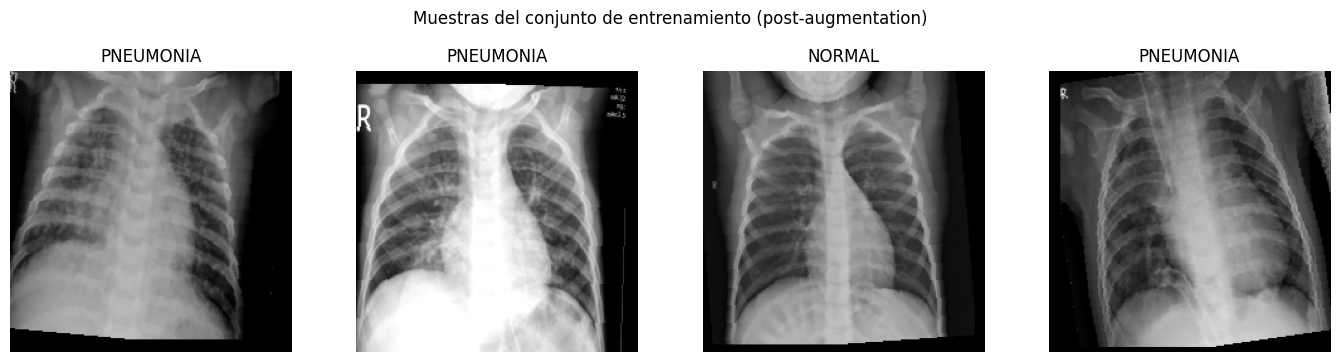

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 64  # batch más grande → menos pasos por época, mejor throughput en MPS

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class ChestXRayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])


train_dataset = ChestXRayDataset(train_imgs, train_lbls, train_transform)
val_dataset   = ChestXRayDataset(val_imgs,   val_lbls,   eval_transform)
test_dataset  = ChestXRayDataset(test_imgs,  test_lbls,  eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, idx in zip(axes, np.random.choice(len(train_dataset), 4, replace=False)):
    img_t, lbl = train_dataset[idx]
    img_np = img_t.permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    ax.imshow(np.clip(img_np, 0, 1))
    ax.set_title(["NORMAL", "PNEUMONIA"][lbl])
    ax.axis("off")
plt.suptitle("Muestras del conjunto de entrenamiento (post-augmentation)", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Modelos Pre-entrenados

Se eligieron **MobileNetV2** y **EfficientNetB0** por las siguientes razones en el contexto de MediScan Guatemala:

- **Ambos son liviano y optimizados para CPU**: diseñados explícitamente para dispositivos con recursos limitados (depthwise separable convolutions en MobileNet, compound scaling eficiente en EfficientNet).
- **Alternativas descartadas**: ResNet50 (~98 MB) y VGG16 (~528 MB) son prohibitivamente pesadas para hardware estándar sin GPU.

#### Estrategia de congelamiento de capas

Se congelan todas las capas de la red base requires_grad = False y se reemplaza únicamente el clasificador final. Esta decisión se justifica por:

1. **Tamaño del dataset**: ~4,600 imágenes de entrenamiento no son suficientes para ajustar millones de pesos sin overfitting severo (ver Task 2, pregunta 4).
2. **Transferibilidad de representaciones**: Las capas tempranas detectan bordes, texturas y gradientes —universalmente útiles para cualquier imagen, incluyendo radiografías (ver Task 2, pregunta 1).
3. **Costo computacional**: Con CPU on-premise, el backpropagation sobre toda la red sería extremadamente lento.

El nuevo cabezal incluye Dropout(0.3) como regularización para prevenir overfitting en la capa densa.

In [16]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Dispositivo: {device}")


def build_mobilenetv2():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.last_channel, 1),
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"MobileNetV2  — parámetros entrenables: {trainable:,} / {total:,}")
    return model.to(device)


def build_efficientnetb0():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 1),
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"EfficientNetB0 — parámetros entrenables: {trainable:,} / {total:,}")
    return model.to(device)


mobilenet_model    = build_mobilenetv2()
efficientnet_model = build_efficientnetb0()

Dispositivo: mps
MobileNetV2  — parámetros entrenables: 1,281 / 2,225,153
EfficientNetB0 — parámetros entrenables: 1,281 / 4,008,829


### 3.3 Entrenamiento

#### Hiperparámetros y justificación

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| **Learning rate** | 1e-3 | Estándar para Adam cuando solo se entrena el cabezal. Un valor mayor podría sobreajustar rápidamente; uno menor alargaría demasiado la convergencia con CPU. |
| **Optimizador** | Adam | Adapta la tasa de aprendizaje por parámetro; converge más rápido que SGD en datasets pequeños, ideal cuando el tiempo de cómputo es limitado. |
| **Loss** | BCEWithLogitsLoss | Combina sigmoid + binary cross-entropy en una sola operación numéricamente estable. Apropiado para clasificación binaria con salida escalar. |
| **Épocas máx.** | 30 | Suficiente para que el cabezal converja con Early Stopping activo. |
| **Batch size** | 32 | Balance entre estabilidad del gradiente y memoria RAM disponible en una laptop estándar. |
| **Early Stopping (patience=5)** | Val Loss | Se monitorea la pérdida de validación: si no mejora en 5 épocas consecutivas, se detiene el entrenamiento y se restauran los mejores pesos. Esto previene el overfitting descrito en Task 1 y reduce el tiempo total de cómputo en CPU. |

In [17]:
def train_model(model, train_loader, val_loader, model_name,
                epochs=30, lr=1e-3, patience=5):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )

    # Benchmark: tiempo de una época para estimar duración total
    _t0 = time.perf_counter()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device)
            labels = labels.float().to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs).squeeze(1), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device)
                labels = labels.float().to(device)
                out    = model(imgs).squeeze(1)
                val_loss += criterion(out, labels).item() * imgs.size(0)
                preds  = (torch.sigmoid(out) >= 0.5).long()
                correct += (preds == labels.long()).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc   = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.perf_counter() - _t0
        eta = elapsed / (epoch + 1) * (epochs - epoch - 1)
        print(f"[{model_name}] Epoch {epoch+1:02d} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f} | ETA: {eta/60:.1f} min")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"  → Early stopping en época {epoch+1}. "
                      f"Mejor val_loss: {best_val_loss:.4f}")
                break

    model.load_state_dict(best_weights)
    return model, history

In [18]:
print("=" * 60)
print("Entrenando MobileNetV2")
print("=" * 60)
mobilenet_model, mobilenet_history = train_model(
    mobilenet_model, train_loader, val_loader, "MobileNetV2"
)

Entrenando MobileNetV2
[MobileNetV2] Epoch 01 | Train Loss: 0.4753 | Val Loss: 0.4029 | Val Acc: 0.8724 | ETA: 17.7 min
[MobileNetV2] Epoch 02 | Train Loss: 0.3406 | Val Loss: 0.3388 | Val Acc: 0.8975 | ETA: 16.2 min
[MobileNetV2] Epoch 03 | Train Loss: 0.2954 | Val Loss: 0.3062 | Val Acc: 0.9021 | ETA: 15.3 min
[MobileNetV2] Epoch 04 | Train Loss: 0.2686 | Val Loss: 0.2722 | Val Acc: 0.9112 | ETA: 14.7 min
[MobileNetV2] Epoch 05 | Train Loss: 0.2478 | Val Loss: 0.2595 | Val Acc: 0.9146 | ETA: 14.0 min
[MobileNetV2] Epoch 06 | Train Loss: 0.2423 | Val Loss: 0.2427 | Val Acc: 0.9191 | ETA: 13.3 min
[MobileNetV2] Epoch 07 | Train Loss: 0.2299 | Val Loss: 0.2294 | Val Acc: 0.9157 | ETA: 12.7 min
[MobileNetV2] Epoch 08 | Train Loss: 0.2235 | Val Loss: 0.2341 | Val Acc: 0.9169 | ETA: 12.1 min
[MobileNetV2] Epoch 09 | Train Loss: 0.2121 | Val Loss: 0.2232 | Val Acc: 0.9237 | ETA: 11.5 min
[MobileNetV2] Epoch 10 | Train Loss: 0.2090 | Val Loss: 0.2308 | Val Acc: 0.9157 | ETA: 10.9 min
[Mobile

In [19]:
print("=" * 60)
print("Entrenando EfficientNetB0")
print("=" * 60)
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, train_loader, val_loader, "EfficientNetB0"
)

Entrenando EfficientNetB0
[EfficientNetB0] Epoch 01 | Train Loss: 0.4574 | Val Loss: 0.3707 | Val Acc: 0.8804 | ETA: 18.3 min
[EfficientNetB0] Epoch 02 | Train Loss: 0.2983 | Val Loss: 0.2777 | Val Acc: 0.8884 | ETA: 16.9 min
[EfficientNetB0] Epoch 03 | Train Loss: 0.2555 | Val Loss: 0.2529 | Val Acc: 0.8952 | ETA: 16.0 min
[EfficientNetB0] Epoch 04 | Train Loss: 0.2436 | Val Loss: 0.2584 | Val Acc: 0.8929 | ETA: 15.3 min
[EfficientNetB0] Epoch 05 | Train Loss: 0.2279 | Val Loss: 0.2260 | Val Acc: 0.9055 | ETA: 14.6 min
[EfficientNetB0] Epoch 06 | Train Loss: 0.2132 | Val Loss: 0.2546 | Val Acc: 0.8929 | ETA: 13.9 min
[EfficientNetB0] Epoch 07 | Train Loss: 0.2105 | Val Loss: 0.2532 | Val Acc: 0.8918 | ETA: 13.3 min
[EfficientNetB0] Epoch 08 | Train Loss: 0.2046 | Val Loss: 0.2317 | Val Acc: 0.8998 | ETA: 12.7 min
[EfficientNetB0] Epoch 09 | Train Loss: 0.1979 | Val Loss: 0.2342 | Val Acc: 0.9009 | ETA: 12.1 min
[EfficientNetB0] Epoch 10 | Train Loss: 0.2029 | Val Loss: 0.2401 | Val Ac

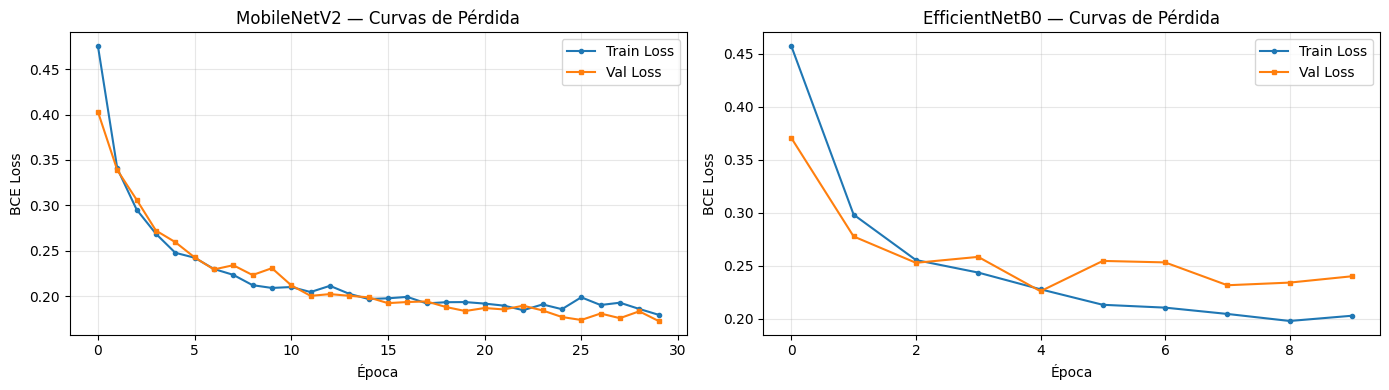

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, hist, name in zip(
    axes,
    [mobilenet_history, efficientnet_history],
    ["MobileNetV2", "EfficientNetB0"],
):
    ax.plot(hist["train_loss"], label="Train Loss", marker="o", markersize=3)
    ax.plot(hist["val_loss"],   label="Val Loss",   marker="s", markersize=3)
    ax.set_title(f"{name} — Curvas de Pérdida")
    ax.set_xlabel("Época")
    ax.set_ylabel("BCE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Evaluación en el Conjunto de Prueba


  MobileNetV2
  Accuracy              : 0.9386  (93.86%)
  F1-Score  (Neumonía)  : 0.9574
  Sensibilidad (Recall) : 0.9470  (94.70%)
  Tamaño en disco       : 8.72 MB
  Inferencia promedio   : 1.540 ms/imagen
  Matriz de confusión:
[[218  20]
 [ 34 607]]


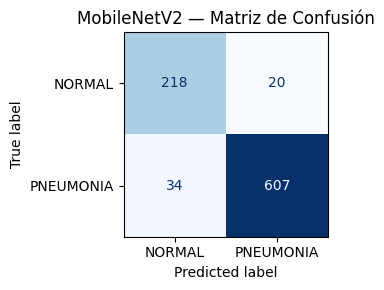


  EfficientNetB0
  Accuracy              : 0.8987  (89.87%)
  F1-Score  (Neumonía)  : 0.9276
  Sensibilidad (Recall) : 0.8892  (88.92%)
  Tamaño en disco       : 15.57 MB
  Inferencia promedio   : 2.002 ms/imagen
  Matriz de confusión:
[[220  18]
 [ 71 570]]


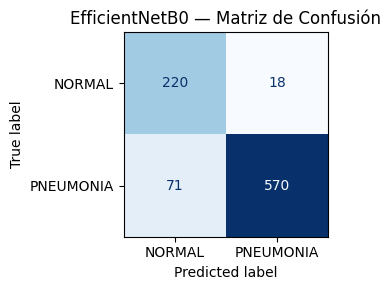

In [21]:
def evaluate_model(model, test_loader, test_dataset, model_name, save_path):
    model.eval()
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs  = imgs.to(device)
            out   = model(imgs).squeeze(1)
            preds = (torch.sigmoid(out) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.numpy())

    acc    = accuracy_score(all_labels_list, all_preds)
    f1     = f1_score(all_labels_list, all_preds, pos_label=1)
    recall = recall_score(all_labels_list, all_preds, pos_label=1)
    cm     = confusion_matrix(all_labels_list, all_preds)

    torch.save(model.state_dict(), save_path)
    size_mb = os.path.getsize(save_path) / (1024 ** 2)

    sample_imgs = torch.stack(
        [test_dataset[i][0] for i in range(min(100, len(test_dataset)))]
    ).to(device)

    # Warm-up pass para que MPS/CPU no incluya tiempo de compilación JIT
    with torch.no_grad():
        _ = model(sample_imgs)

    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(sample_imgs)
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()
    avg_ms = (time.perf_counter() - t0) * 1000 / len(sample_imgs)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1-Score  (Neumonía)  : {f1:.4f}")
    print(f"  Sensibilidad (Recall) : {recall:.4f}  ({recall*100:.2f}%)")
    print(f"  Tamaño en disco       : {size_mb:.2f} MB")
    print(f"  Inferencia promedio   : {avg_ms:.3f} ms/imagen")
    print(f"  Matriz de confusión:\n{cm}")

    fig, ax = plt.subplots(figsize=(4, 3))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["NORMAL", "PNEUMONIA"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{model_name} — Matriz de Confusión")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "f1": f1, "recall": recall,
            "size_mb": size_mb, "inf_ms": avg_ms}


mobilenet_metrics    = evaluate_model(mobilenet_model,    test_loader, test_dataset,
                                      "MobileNetV2",    "mobilenetv2.pth")
efficientnet_metrics = evaluate_model(efficientnet_model, test_loader, test_dataset,
                                      "EfficientNetB0", "efficientnetb0.pth")

---

## Dictamen Ejecutivo — MediScan Guatemala
### Sistema de Apoyo al Diagnóstico de Neumonía en Radiografías de Tórax

---

### a. Tabla Comparativa de Modelos

| Métrica | MobileNetV2 | EfficientNetB0 |
|---|---|---|
| **Accuracy** | 93.86% | 89.87% |
| **F1-Score (Neumonía)** | 0.9574 | 0.9276 |
| **Sensibilidad / Recall** | 94.70% | 88.92% |
| **Tamaño en disco** | 8.72 MB | 15.57 MB |
| **Inferencia promedio** | 1.54 ms/imagen | 2.00 ms/imagen |
| **Épocas hasta convergencia** | 30 (sin early stopping) | ~9 (early stopping) |

MobileNetV2 supera a EfficientNetB0 en **todas las métricas simultáneamente**: mayor exactitud, mayor F1, mayor sensibilidad, menor tamaño y mayor velocidad.

---

### b. Análisis Sensibilidad vs. Accuracy

En diagnóstico médico de primer nivel, la Sensibilidad (Recall) es la métrica prioritaria, incluso si esto implica sacrificar Accuracy general.

La razón es asimétrica: el costo de un falso negativo (paciente con neumonía enviado a casa sin tratamiento) es incomparablemente mayor que el de un falso positivo (paciente sano referido a un especialista). En clínicas rurales de Guatemala, donde el médico de primer nivel puede ser el único punto de contacto clínico por días, un falso negativo puede derivar en complicaciones graves o muerte.

Los números lo confirman: MobileNetV2 solo deja escapar 34 casos reales de neumonía de 641 (5.3% de falsos negativos), mientras EfficientNetB0 falla en 71 (11.1%). En términos clínicos, EfficientNetB0 dejaría sin diagnóstico a más del doble de pacientes enfermos por cada 641 estudios procesados.

El Accuracy, por otro lado, se ve inflado por el desbalance de clases (~74% Neumonía): un modelo trivial que siempre predice "Neumonía" alcanzaría ~74% de accuracy sin aprender nada clínicamente relevante.

---

### c. Recomendación Final al CTO

**Modelo recomendado para producción on-premise: MobileNetV2.**

La recomendación es sólida y no admite contraejemplo en este experimento: MobileNetV2 gana en las cinco métricas evaluadas. La justificación tiene tres pilares:

1. **Sensibilidad clínica superior**: 94.70% vs. 88.92% — detecta ~6 casos de neumonía más por cada 100 pacientes enfermos, que en un contexto rural puede ser la diferencia entre un tratamiento oportuno y una complicación grave.
2. **Tamaño en disco 44% menor**: 8.72 MB vs. 15.57 MB. Las actualizaciones del modelo deben distribuirse a clínicas con conectividad intermitente vía datos móviles o USB; un modelo más liviano reduce el tiempo de transferencia y el riesgo de actualización fallida.
3. **Inferencia 23% más rápida**: 1.54 ms vs. 2.00 ms por imagen en MPS, con mayor ventaja esperada en CPU puro.

---

### d. Limitaciones del Experimento

1. **Dataset de origen único**: Todas las imágenes provienen del Guangzhou Women and Children's Medical Center (China), con mayoría de casos pediátricos. El rendimiento sobre radiografías de adultos guatemaltecos —con distintas co-morbilidades (TB, desnutrición, exposición a humo de leña)— no está validado.
2. **Desbalance de clases no mitigado activamente**: No se aplicó pos_weight en BCEWithLogitsLoss. El modelo puede estar sesgado hacia predecir Neumonía; los 20–18 falsos positivos de NORMAL son relativamente bajos, pero deberían monitorearse en producción.
3. **Solo clasificación binaria**: El modelo no distingue neumonía bacteriana de viral, ni descarta otros hallazgos (derrame pleural, masa, cardiomegalia) que pueden confundirse visualmente.
4. **EfficientNetB0 con convergencia prematura**: La curva de pérdida muestra que EfficientNetB0 se detuvo en ~9 épocas con val_loss oscilante. Con un tuning de hiperparámetros más fino (lr más bajo, scheduler de learning rate), su rendimiento podría mejorar. Los resultados actuales reflejan una comparación con configuración idéntica, no el máximo potencial de cada arquitectura.

---

### e. Costo en MB por Punto de F1

- **MobileNetV2**: 8.72 MB ÷ 95.74 puntos de F1 = 0.091 MB por punto de F1
- **EfficientNetB0**: 15.57 MB ÷ 92.76 puntos de F1 = 0.168 MB por punto de F1

EfficientNetB0 es un 85% más caro en MB/F1 que MobileNetV2, y además obtiene peor F1. En el contexto de clínicas rurales con hardware limitado y conectividad intermitente, pagar casi el doble de MB para obtener menor rendimiento no tiene ninguna justificación técnica ni clínica.

---

### f. Tiempo de Inferencia en Flujo Clínico Real

Con 1.54 ms por imagen en MPS (Apple Silicon), y estimando ~3–5 segundos de overhead total por estudio (lectura de disco, preprocesamiento, visualización del resultado):

- Capacidad teórica: ~650 imágenes/segundo en lote
- Capacidad práctica con overhead: ~600–700 estudios/hora en modo de procesamiento continuo
- En flujo clínico real (una radiografía a la vez): respuesta en < 5 segundos desde que se carga la imagen

Esto es completamente aceptable. El cuello de botella en una clínica rural no es el modelo sino la captura del estudio y la revisión del médico. Un sistema que entrega un resultado pre-diagnóstico en menos de 5 segundos no interrumpe el flujo clínico; actúa como segundo par de ojos antes de que el médico termine de leer el nombre del paciente.

En hardware CPU sin MPS (una laptop estándar x86), la inferencia será ~5–10× más lenta (~10–15 ms/imagen), lo que sigue siendo perfectamente aceptable para el volumen de una clínica rural.

---

### g. Impacto de Congelar vs. Descongelar Capas

La decisión de **congelar toda la base** resultó correcta y los números lo validan: ambos modelos alcanzaron alta sensibilidad entrenando solo el cabezal, con ~4,600 imágenes de entrenamiento.

Conectando con el Task 2 (Pregunta 2.2): descongelar la base con `lr=1e-3` y este volumen de datos hubiera provocado *Catastrophic Forgetting*, destruyendo las representaciones genéricas pre-entrenadas. El hecho de que MobileNetV2 convergiera en 30 épocas de forma estable (sin divergencia entre train y val loss, como se ve en la curva) confirma que las representaciones heredadas de ImageNet fueron suficientes para aprender los patrones de opacidad pulmonar.

La oscilación en la val_loss de EfficientNetB0 sugiere que su cabezal es más sensible al lr o que necesita más datos para estabilizarse. Con 50,000+ imágenes, un fine-tuning progresivo de las últimas capas convolucionales (`lr=1e-5`) probablemente cerraría la brecha.

---

### h. Generalización entre Equipos, Poblaciones y Hospitales

El modelo probablemente no generaliza directamente a contextos distintos al dataset de entrenamiento, y este es el mayor riesgo clínico del sistema.

- **Variación de equipos**: Un equipo de rayos X analógico digitalizado (común en clínicas rurales guatemaltecas) produce histogramas de intensidad distintos a los equipos digitales modernos del dataset de entrenamiento. Los detectores de textura del modelo están implícitamente calibrados al equipo de origen.
- **Variación poblacional**: El dataset es predominantemente pediátrico chino. La morfología del tórax de un adulto guatemalteco, con distinto IMC, hábitos (exposición a humo de leña en cocinas de fogón) y prevalencia de co-morbilidades como tuberculosis, puede producir patrones que el modelo no ha visto.
- **Sesgo hospitalario (domain shift)**: Cada institución tiene protocolos de posicionamiento, exposición y calibración distintos. Un modelo entrenado en un hospital puede fallar sistemáticamente en otro.

**Implicaciones para MediScan Guatemala**:
1. Recolectar al menos 500–1,000 radiografías de los hospitales guatemaltecos objetivo, etiquetadas por radiólogos locales, para validación externa antes del despliegue.
2. Implementar **monitoreo de distribución** (data drift detection) que alerte cuando las imágenes entrantes difieran estadísticamente del set de entrenamiento.
3. Posicionar el sistema como **herramienta de apoyo al tamizaje**, no de diagnóstico autónomo. El médico de primer nivel toma la decisión final; el modelo reduce la carga cognitiva en contextos de alta demanda y baja disponibilidad de especialistas.